# Plotting a graph over time of the affilitions

In [1]:
import pandas as pd
import numpy as np
JPE = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/JPE_Melted_Weights_applied.xlsx') 
print(JPE.shape)
JPE = JPE[['Article_ID','Weight','Affiliation','year']]
JPE = JPE.reset_index(drop=True)

QJE = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/QJE_Melted_Weights_applied.xlsx') 
print(QJE.shape)
QJE = QJE[['Article_ID','Weight','Affiliation','year']]
QJE = QJE.reset_index(drop=True)

RES = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/RES_Melted_Weights_applied.xlsx') 
print(RES.shape)
RES = RES[['Article_ID','Weight','Affiliation','year']]
RES = RES.reset_index(drop=True)

AER = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/AER_Melted_Weights_applied.xlsx') 
print(AER.shape)
AER = AER[['Article_ID','Weight','Affiliation','year']]
AER = AER.reset_index(drop=True)

ECTA = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/ECTA_Melted_Weights_applied.xlsx') 
print(ECTA.shape)
ECTA = ECTA[['Article_ID','Weight','Affiliation','year']]
ECTA = ECTA.reset_index(drop=True)


(6304, 7)
(5172, 7)
(4309, 7)
(15282, 7)
(6726, 7)


In [2]:
melted_master_condenced = pd.concat([JPE, QJE, RES, AER, ECTA])

In [3]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1945), '[1940,1944]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1945) & (melted_master_condenced['year'] < 1950), '[1945,1950]', melted_master_condenced['decade'])

melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1955), '[1950,1954]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1955) & (melted_master_condenced['year'] < 1960), '[1955,1959]', melted_master_condenced['decade'])

melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1965), '[1960,1964]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1965) & (melted_master_condenced['year'] < 1970), '[1965,1969]', melted_master_condenced['decade'])

melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1975), '[1970,1974]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1975) & (melted_master_condenced['year'] < 1980), '[1975,1979]', melted_master_condenced['decade'])

melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1985), '[1980,1984]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1985) & (melted_master_condenced['year'] < 1990), '[1985,1989]', melted_master_condenced['decade'])

melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 1995), '[1990,1994]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1995) & (melted_master_condenced['year'] < 2000), '[1995,1999]', melted_master_condenced['decade'])

melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2005), '[2000,2004]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2005) & (melted_master_condenced['year'] < 2011), '[2005,2010]', melted_master_condenced['decade'])

print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight              Affiliation  year       decade
0     1825913     1.0     Washington Dc (City)  1940  [1940,1944]
1     1825908     1.0    University Of Chicago  1940  [1940,1944]
2     1824384     1.0      Columbia University  1940  [1940,1944]
3     1824382     1.0       Cornell University  1940  [1940,1944]
4     1824381     1.0  University Of Edinburgh  1940  [1940,1944]
      Article_ID  Weight                Affiliation  year       decade
6721    25621405     1.0    University Of Rochester  2010  [2005,2010]
6722    25621404     0.5                  Hec Paris  2010  [2005,2010]
6723    25621403     0.5    University Of Minnesota  2010  [2005,2010]
6724    25621401     0.5  University College London  2010  [2005,2010]
6725    40928462     0.5         Harvard University  2010  [2005,2010]


# Ranking the Universities based on their number of papers per published per decade

In [4]:
#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research'])
melted_master_condenced = melted_master_condenced[~mask_journal]

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(25,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(25, 6)
University Of California, Berkeley


      Article_ID    Weight                         Affiliation       decade  \
441      1910731  1.000000  University Of California, Berkeley  [1940,1944]   
949      1812743  1.000000  University Of California, Berkeley  [1945,1950]   
1460     1807704  0.500000  University Of California, Berkeley  [1950,1954]   
709      1826697  1.000000  University Of California, Berkeley  [1955,1959]   
946      1913736  0.333333  University Of California, Berkeley  [1960,1964]   

      aff_cum_counts_yearly  
441                5.050000  
949               13.833333  
1460              21.500000  
709               16.000000  
946               29.583333  
(14, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1670870116.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [5]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.shape)

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
print(b.shape)

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:12: SettingWithCop

(14, 5)
(14, 5)
(14, 5)
(14, 5)
(14, 5)
(14, 5)
(14, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:47: SettingWithC

(14, 5)
(14, 5)
(14, 5)
(14, 5)
(14, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()


...

/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:77: SettingWithC

(14, 5)
(14, 5)
(14, 5)
(12, 5)
(14, 5)
(14, 5)
(13, 5)
(14, 5)
(14, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:112: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()


(14, 5)
(14, 5)
(14, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_6152/1100585584.py:122: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [6]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(347, 5)
(347, 6)
       Article_ID    Weight                                     Affiliation  \
15036    27804924  0.333333                                 Duke University   
6725     40928462  0.500000                              Harvard University   
4198     40835860  0.333333                  Hebrew University Of Jerusalem   
14996    41038774  0.500000  London School Of Economics & Political Science   
15034    27804930  0.333333           Massachusetts Institute Of Technology   
15043    27805057  0.250000                             New York University   
15090    27804996  0.333333                         Northwestern University   
15007    27804920  1.000000                            Princeton University   
15033    27804933  0.333333                             Stanford University   
15071    27804986  0.333333              University Of California, Berkeley   
15060    27804965  0.250000           University Of California, Los Angeles   
15020    41038752  0.333333       

In [7]:
ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [8]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})

In [10]:
ranked['aff_cum_sum_decade'] = ranked['aff_cum_sum_decade'].astype(int)

ranked = ranked.fillna(0)

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)
invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].astype(int)

#invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
#invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].astype(int)
##invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].astype(int)
#invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].astype(int)
#invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].astype(int)
#invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].astype(int)
#invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
invert_pivot

Year Bucket,"[1940,1944]","[1945,1950]","[1950,1954]","[1955,1959]","[1960,1964]","[1965,1969]","[1970,1974]","[1975,1979]","[1980,1984]","[1985,1989]","[1990,1994]","[1995,1999]","[2000,2004]","[2005,2010]",Total papers,Average Paper per decade
Affiliation,,,,,,,,,,,,,,,,
Harvard University,53.0,72.0,58.0,38.0,53.0,63.0,109.0,92.0,79.0,89.0,91.0,101.0,88.0,133.0,1119,149
University Of Chicago,47.0,56.0,48.0,38.0,59.0,76.0,84.0,64.0,67.0,58.0,80.0,66.0,85.0,88.0,916,122
Massachusetts Institute Of Technology,21.0,15.0,25.0,43.0,43.0,64.0,56.0,53.0,75.0,84.0,81.0,70.0,73.0,71.0,774,103
Stanford University,12.0,10.0,32.0,30.0,40.0,32.0,55.0,56.0,59.0,73.0,59.0,51.0,64.0,83.0,656,87
Princeton University,19.0,19.0,25.0,13.0,26.0,38.0,46.0,37.0,67.0,74.0,56.0,44.0,58.0,66.0,588,78
Yale University,17.0,22.0,28.0,30.0,42.0,57.0,59.0,51.0,58.0,51.0,52.0,34.0,41.0,44.0,586,78
"University Of California, Berkeley",5.0,13.0,21.0,16.0,29.0,48.0,32.0,41.0,44.0,47.0,45.0,32.0,47.0,86.0,506,67
Northwestern University,3.0,9.0,14.0,23.0,23.0,19.0,32.0,46.0,47.0,49.0,70.0,40.0,45.0,74.0,494,65
University Of Pennsylvania,14.0,5.0,6.0,19.0,19.0,46.0,36.0,38.0,48.0,64.0,45.0,38.0,42.0,46.0,466,62


<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

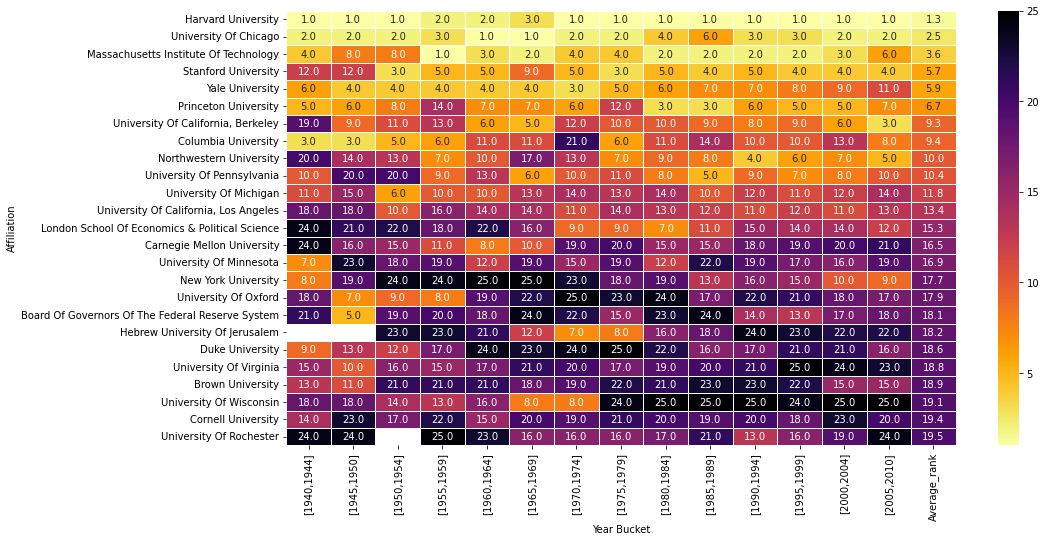

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
ranked['Rank'] = ranked['Rank'].astype(int)
#print(ranked.head())
invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot['Average_rank'] = invert_pivot.mean(axis=1)
#print(invert_pivot)
#print(invert_pivot.head())
invert_pivot = invert_pivot.sort_values(by='Average_rank', ascending=True)
f, ax = plt.subplots(figsize=(15, 8))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

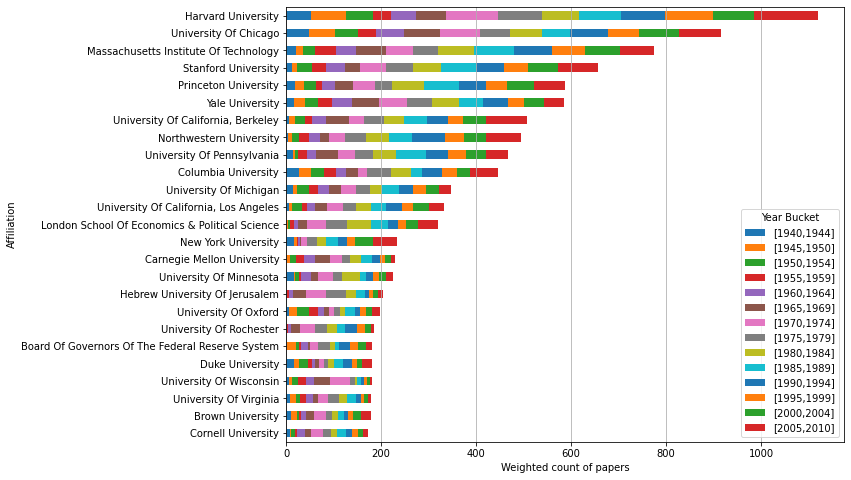

In [12]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
#print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)
ax = p.plot.barh(stacked=True, figsize=(10, 8))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Weighted count of papers')
plt.grid(axis = 'x')
plt.show()
